In [1]:
# importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn import svm

In [2]:
# Loading the academic performance dataset to a pandas DataFrame
performance_dataset = pd.read_csv('StudentPerformanceFactors.csv')

In [3]:
performance_dataset

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [4]:
performance_dataset.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [5]:
for col in ['Parental_Education_Level',
            'Distance_from_Home',
            'Teacher_Quality']:
  performance_dataset[col].fillna(
      performance_dataset[col].mode()[0],
      inplace=True
  )

C:\Users\DANIEL\AppData\Local\Temp\ipykernel_15480\2157695464.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  performance_dataset[col].fillna(


In [6]:
performance_dataset.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [7]:
performance_dataset

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


Feature Encoding

In [8]:
# Convert the Binary Columns
binary_cols= {
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Internet_Access': {'No': 0, 'Yes': 1},
    'Learning_Disabilities': {'No': 0, 'Yes': 1},
    'Gender': {'Male': 1, 'Female': 0},
    'School_Type': {'Public': 0, 'Private': 1}
}

for col, mapping in binary_cols.items():
  performance_dataset[col] = performance_dataset[col].map(mapping)


In [9]:
order_mapping = {'Low': 1, 'Medium': 2, 'High': 3}

ordinal_cols = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income',
    'Teacher_Quality'
]

for col in ordinal_cols:
    performance_dataset[col] = performance_dataset[col].map(order_mapping)


In [10]:
education_mapping = {
    'High School': 1,
    'College': 2,
    'Postgraduate': 3
}

performance_dataset['Parental_Education_Level'] = performance_dataset['Parental_Education_Level'].map(education_mapping)


In [11]:
distance_mapping = {
    'Near': 1,
    'Moderate': 2,
    'Far': 3
}

performance_dataset['Distance_from_Home'] = performance_dataset['Distance_from_Home'].map(distance_mapping)


In [12]:
peer_mapping = {
    'Negative': 1,
    'Neutral': 2,
    'Positive': 3
}

performance_dataset['Peer_Influence'] = performance_dataset['Peer_Influence'].map(peer_mapping)


In [13]:
performance_dataset.dtypes

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement          int64
Access_to_Resources           int64
Extracurricular_Activities    int64
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level              int64
Internet_Access               int64
Tutoring_Sessions             int64
Family_Income                 int64
Teacher_Quality               int64
School_Type                   int64
Peer_Influence                int64
Physical_Activity             int64
Learning_Disabilities         int64
Parental_Education_Level      int64
Distance_from_Home            int64
Gender                        int64
Exam_Score                    int64
dtype: object

In [14]:
correlation = performance_dataset.corr()
print(correlation)


                            Hours_Studied  Attendance  Parental_Involvement  \
Hours_Studied                    1.000000   -0.009908             -0.016092   
Attendance                      -0.009908    1.000000             -0.009313   
Parental_Involvement            -0.016092   -0.009313              1.000000   
Access_to_Resources             -0.005452   -0.011508             -0.026557   
Extracurricular_Activities      -0.006017   -0.002222             -0.021881   
Sleep_Hours                      0.010977   -0.015918             -0.007945   
Previous_Scores                  0.024846   -0.020186             -0.021074   
Motivation_Level                -0.010396   -0.005010             -0.022393   
Internet_Access                  0.005038   -0.018318              0.012457   
Tutoring_Sessions               -0.014282    0.014324             -0.002107   
Family_Income                    0.000762   -0.012774              0.012383   
Teacher_Quality                 -0.003903   -0.00096

In [15]:
performance_dataset

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,3,0,7,73,1,1,0,1,2,0,3,3,0,1,1,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,0,1,4,0,2,2,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,0,2,4,0,3,1,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,0,1,4,0,1,2,1,71
4,19,92,2,2,1,6,65,2,1,3,2,3,0,2,4,0,2,1,0,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,3,2,0,7,76,2,1,1,3,2,0,3,2,0,1,1,0,68
6603,23,76,3,2,0,8,81,2,1,3,1,3,0,3,2,0,1,1,0,69
6604,20,90,2,1,1,6,65,1,1,3,1,2,0,1,2,0,3,1,0,68
6605,10,86,3,3,1,6,91,3,1,2,1,2,1,3,3,0,1,3,0,68


<Axes: >

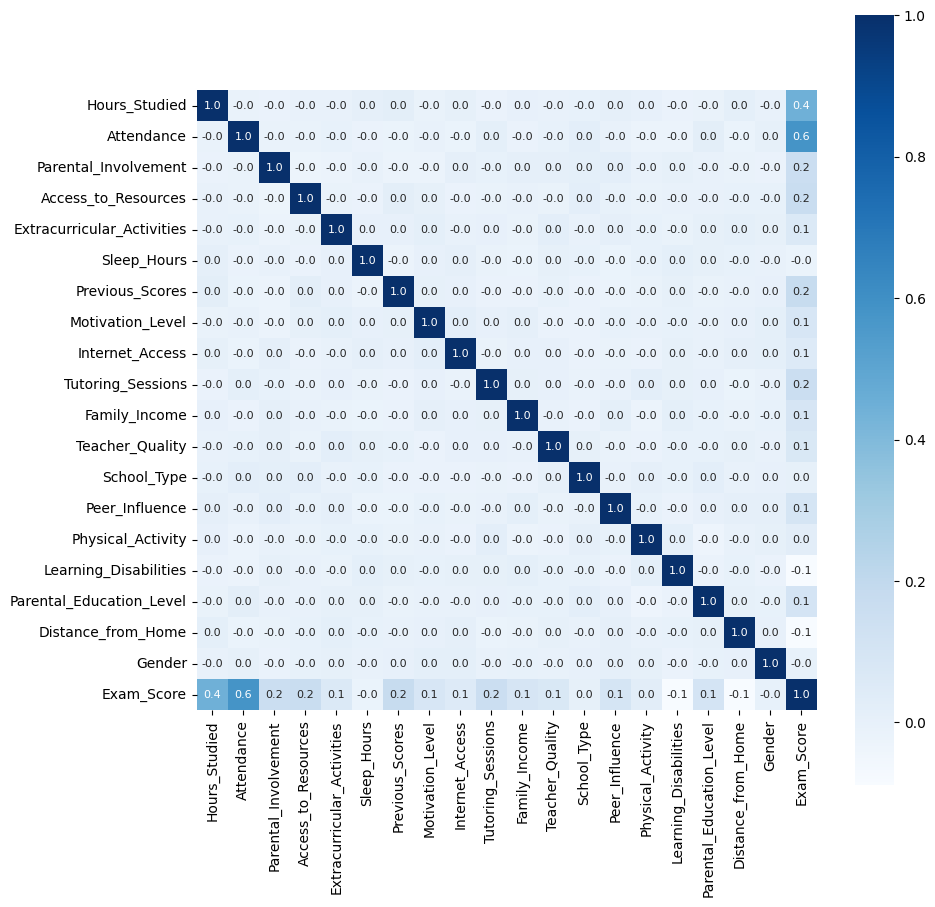

In [16]:
# constructing a heatmap to understand to understand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size':8}, cmap='Blues')

In [17]:
x = performance_dataset.drop("Exam_Score", axis=1)
y = performance_dataset["Exam_Score"]

In [18]:
print(x.shape)
print(y.shape)

(6607, 19)
(6607,)


In [19]:
# Split the Dataset
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.2,random_state=2)

In [20]:
print(x.shape, X_train.shape, X_test.shape)

(6607, 19) (5285, 19) (1322, 19)


In [21]:
print(performance_dataset.columns)

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')


In [22]:
# Training the model
model = RandomForestRegressor(n_estimators=100, random_state=2)
model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [23]:
# Testing the model
Y_pred = model.predict(X_test)
print(Y_pred)

[66.97 65.41 72.7  ... 66.32 69.06 64.3 ]


In [24]:
# Evaluating the Performance
from sklearn.metrics import r2_score, mean_squared_error
print("R2 Score:", r2_score(Y_test, Y_pred))
print("Mean Absolute Error:", mean_squared_error(Y_test, Y_pred))

R2 Score: 0.5878298620431281
Mean Absolute Error: 7.09075158850227


In [25]:
# Gradient Boosting Regressor Comparison
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=2)
gb_model.fit(X_train, Y_train)
gb_pred = gb_model.predict(X_test)
print("Gradient Boosting Results:")
print("R2 Score:", r2_score(Y_test, gb_pred))
print("Mean Absolute Error:", mean_squared_error(Y_test, gb_pred))

Gradient Boosting Results:
R2 Score: 0.63119763522097
Mean Absolute Error: 6.344675931311489


In [26]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}
grid_search = GridSearchCV(GradientBoostingRegressor(random_state=2), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, Y_train)
print('Best Parameters:', grid_search.best_params_)
best_gb_model = grid_search.best_estimator_
best_gb_pred = best_gb_model.predict(X_test)
print('Tuned Gradient Boosting Results:')
print('R2 Score:', r2_score(Y_test, best_gb_pred))
print('Mean Absolute Error:', mean_squared_error(Y_test, best_gb_pred))

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Tuned Gradient Boosting Results:
R2 Score: 0.6443089403202416
Mean Absolute Error: 6.119116146896139


## Feature Importance
Feature importance shows which input variables have the biggest impact on the model's predictions. This helps you understand what factors most influence student performance and can guide future data collection or interventions. We'll visualize the feature importances from the tuned Gradient Boosting model.

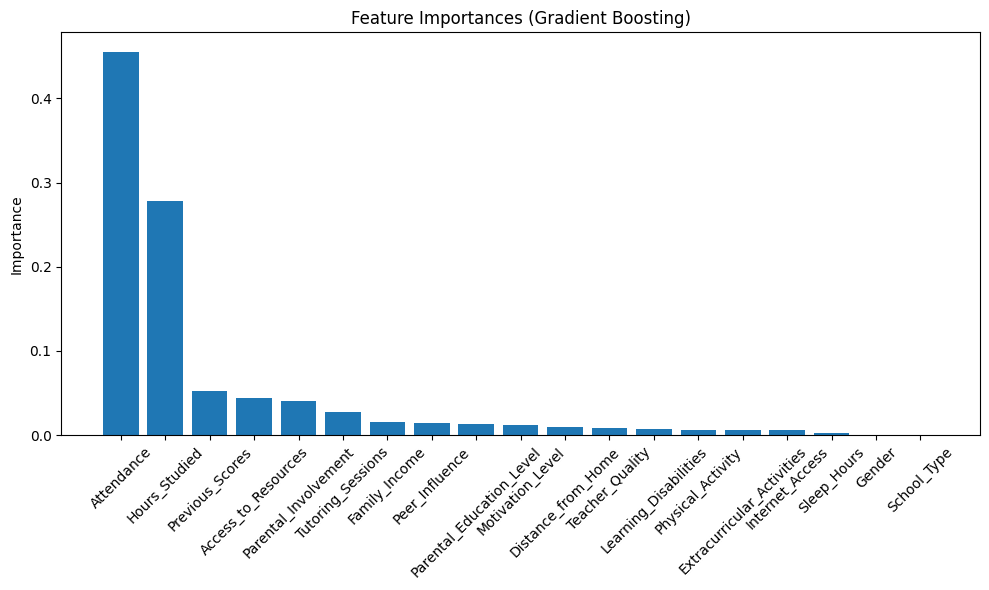

In [27]:
importances = best_gb_model.feature_importances_
features = X_train.columns
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.title('Feature Importances (Gradient Boosting)')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), features[indices], rotation=45)
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [28]:
threshold = 0.0003
# Create a DataFrame for feature importances
importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})
high_importance_features = importances_df[importances_df['Importance'] >= threshold]['Feature'].tolist()
print("Features to retain:", high_importance_features)

Features to retain: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home']


In [29]:
# Update dataset to keep only high-importance features
x_reduced = x[high_importance_features]
print("Reduced feature set shape:", x_reduced.shape)

# Split the reduced dataset
X_train_reduced, X_test_reduced, Y_train, Y_test = train_test_split(x_reduced, y, test_size=0.2, random_state=2)

# Retrain Gradient Boosting model with reduced features
gb_model_reduced = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=2)
gb_model_reduced.fit(X_train_reduced, Y_train)
gb_pred_reduced = gb_model_reduced.predict(X_test_reduced)

# Evaluate performance
from sklearn.metrics import mean_absolute_error
print("Retrained Model Results:")
print("R2 Score:", r2_score(Y_test, gb_pred_reduced))
print("Mean Absolute Error:", mean_absolute_error(Y_test, gb_pred_reduced))

Reduced feature set shape: (6607, 17)
Retrained Model Results:
R2 Score: 0.6441801937338988
Mean Absolute Error: 0.7907116560418966


In [30]:
def predict_student_performance(input_data, model, feature_list):
    # convert input data to a DataFrame
    df = pd.DataFrame([input_data])
    df = df[feature_list]

    prediction = model.predict(df)
    return prediction[0]

In [31]:
# Example new student data with all required features
new_student = {
    'Hours_Studied': 13,
    'Attendance': 69,
    'Parental_Involvement': 2,  # 1=Low, 2=Medium, 3=High
    'Access_to_Resources': 1,   # 1=Low, 2=Medium, 3=High
    'Extracurricular_Activities': 1,  # 0=No, 1=Yes
    'Sleep_Hours': 5,
    'Previous_Scores': 68,
    'Motivation_Level': 1,      # 1=Low, 2=Medium, 3=High
    'Internet_Access': 1,       # 0=No, 1=Yes
    'Tutoring_Sessions': 0,
    'Family_Income': 3,         # 1=Low, 2=Medium, 3=High
    'Teacher_Quality': 2,       # 1=Low, 2=Medium, 3=High
    'Peer_Influence': 3,        # 1=Negative, 2=Neutral, 3=Positive
    'Physical_Activity': 1,
    'Learning_Disabilities': 1, # 0=No, 1=Yes
    'Parental_Education_Level': 1, # 1=High School, 2=College, 3=Postgraduate
    'Distance_from_Home': 2    # 1=Near, 2=Moderate, 3=Far
}

predicted_score = predict_student_performance(new_student, gb_model_reduced, high_importance_features)
print("Predicted Exam Score:", predicted_score)

if (predicted_score >= 40):
    print('You have passed the exam !')
else:
    print('Work harder! You have not reached the passmark')




Predicted Exam Score: 59.909282508650364
You have passed the exam !


In [32]:
import pickle

# Save the trained model
pickle.dump(gb_model_reduced, open('gb_model_reduced.pkl', 'wb'))